**Project 1.1**: Real Estate Price Prediction System

**Business Challenge**
A real estate company is struggling with pricing inconsistencies across their property
listings. Manual pricing by agents leads to overpriced properties sitting on the market for
months and underpriced properties selling too quickly, leaving money on the table. The
company needs a data-driven pricing system that can accurately predict property values
based on various features to optimize listing prices and improve sales velocity.

**Problem Context**

The company has historical data on 50,000+ property transactions including square
footage, number of bedrooms/bathrooms, lot size, year built, location coordinates, school
district ratings, and proximity to amenities. Currently, pricing decisions rely heavily on
agent experience and comparable sales, resulting in a 23% price adjustment rate after
initial listing and an average time on market of 87 days.

**Expected Outcomes**
• Reduce pricing adjustments from 23% to under 8%
• Decrease average time on market by 30-40 days
• Increase agent confidence in initial pricing decisions
• Provide transparent pricing justification to clients

**Key Performance Metrics**
• Mean Absolute Error (MAE) under $25,000
• R-squared value above 0.82
• Prediction accuracy within ±10% for 85% of properties

**1. Upload and Load Dataset**

In [ ]:
# Import pandas for data handling
import pandas as pd

# Read the CSV file directly from its path
df = pd.read_csv('/content/sample_data/Project_1_1.csv')

# Display first 5 rows
df.head()

,property_id,square_footage,bedrooms,bathrooms,lot_size_sqft,year_built,latitude,longitude,school_rating,distance_to_downtown_miles,distance_to_transit_miles,garage_spaces,has_pool,has_fireplace,condition_score,neighborhood_type,price
0,PROP_00001,1660,3,2.5,8871,2008,34.417268,-118.044350,6,6.39,1.67,3,0,1,6,Rural,580000
1,PROP_00002,4572,3,4.3,13578,2018,33.906591,-118.017983,5,11.45,3.75,0,1,1,2,Suburban,1170000
2,PROP_00003,3892,3,3.5,4972,1990,33.643281,-117.742223,10,15.30,4.86,0,1,0,7,Suburban,1128000
3,PROP_00004,1266,3,3.2,5922,1988,34.214719,-118.218082,10,21.90,2.25,1,0,0,8,Suburban,504000
4,PROP_00005,4244,4,1.2,6997,2022,33.793353,-118.181960,6,3.84,4.32,3,0,0,1,Urban,1069000


**2. Data Preprocessing & Feature Engineering**

In [ ]:
# Import numpy for numerical operations
import numpy as np

# Drop property_id (not useful for prediction)
df = df.drop(columns=['property_id'])

# Create new features to improve model performance

# Property age (important pricing factor)
df['property_age'] = 2026 - df['year_built']

# Bedroom to bathroom ratio (captures layout efficiency)
df['bed_bath_ratio'] = df['bedrooms'] / (df['bathrooms'] + 0.1)

# Square footage per bedroom (captures space distribution)
df['sqft_per_bedroom'] = df['square_footage'] / (df['bedrooms'] + 1)

# Convert categorical variable into numerical (one-hot encoding)
df = pd.get_dummies(df, columns=['neighborhood_type'], drop_first=True)

# Check updated dataset
df.head()

,square_footage,bedrooms,bathrooms,lot_size_sqft,year_built,latitude,longitude,school_rating,distance_to_downtown_miles,distance_to_transit_miles,garage_spaces,has_pool,has_fireplace,condition_score,price,property_age,bed_bath_ratio,sqft_per_bedroom,neighborhood_type_Suburban,neighborhood_type_Urban
0,1660,3,2.5,8871,2008,34.417268,-118.044350,6,6.39,1.67,3,0,1,6,580000,18,1.153846,415.0,False,False
1,4572,3,4.3,13578,2018,33.906591,-118.017983,5,11.45,3.75,0,1,1,2,1170000,8,0.681818,1143.0,True,False
2,3892,3,3.5,4972,1990,33.643281,-117.742223,10,15.30,4.86,0,1,0,7,1128000,36,0.833333,973.0,True,False
3,1266,3,3.2,5922,1988,34.214719,-118.218082,10,21.90,2.25,1,0,0,8,504000,38,0.909091,316.5,True,False
4,4244,4,1.2,6997,2022,33.793353,-118.181960,6,3.84,4.32,3,0,0,1,1069000,4,3.076923,848.8,False,True


**3. Outlier Detection**

This section focuses on identifying and handling outliers in the dataset. Outliers can significantly skew model training and lead to less accurate predictions. We will use box plots for visual inspection and the Interquartile Range (IQR) method for quantitative detection of outliers in key numerical features.

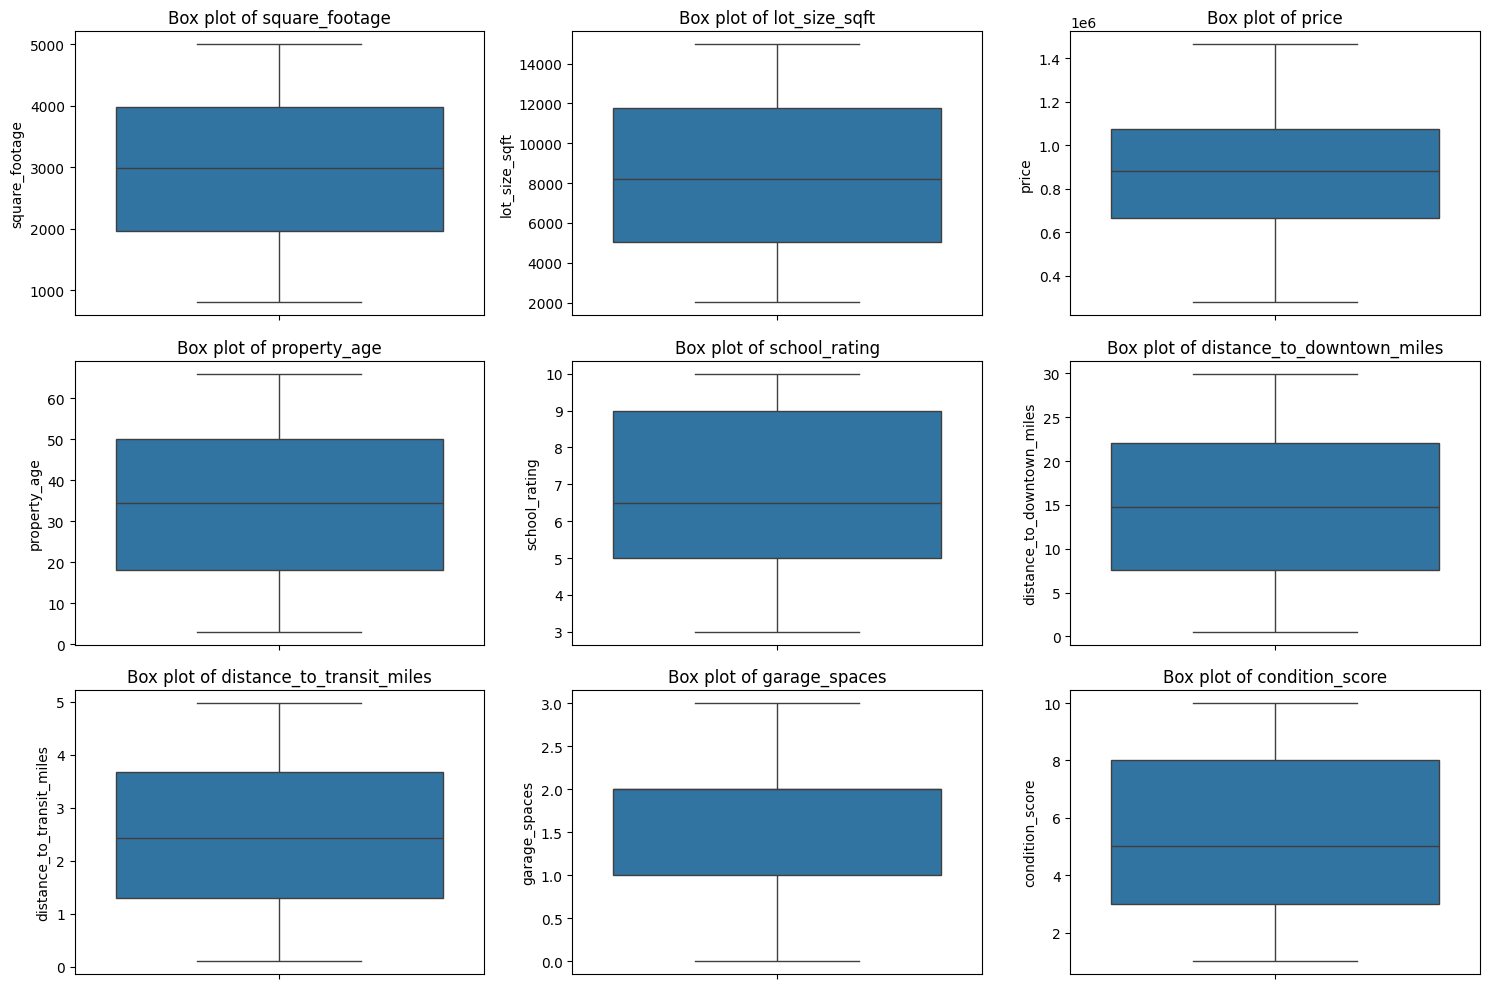

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns likely to have outliers
numerical_cols = ['square_footage', 'lot_size_sqft', 'price', 'property_age', 'school_rating', 'distance_to_downtown_miles', 'distance_to_transit_miles', 'garage_spaces', 'condition_score']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Columns to check for outliers
outlier_columns = ['price', 'square_footage', 'lot_size_sqft', 'property_age']

print("\nOutlier Detection using IQR Method:")
for col in outlier_columns:
    outliers = detect_outliers_iqr(df, col)
    if not outliers.empty:
        print(f"- Column '{col}': {len(outliers)} outliers found ({len(outliers)/len(df)*100:.2f}% of data).")
    else:
        print(f"- Column '{col}': No outliers found.")


Outlier Detection using IQR Method:
- Column 'price': No outliers found.
- Column 'square_footage': No outliers found.
- Column 'lot_size_sqft': No outliers found.
- Column 'property_age': No outliers found.


**4. Split Data into Features and Target**

In [ ]:
# Separate input features (X) and target variable (y)
X = df.drop(columns=['price'])
y = df['price']

# Import train-test split function
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**5. Train Multiple Models**

In [ ]:
# Import models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize models

# 1. Simple Multivariate Linear Regression (baseline)
linear_model = LinearRegression()

# 2. Ridge Regression (handles multicollinearity)
ridge_model = Ridge(alpha=1.0)

# 3. Lasso Regression (feature selection)
lasso_model = Lasso(alpha=0.1)

# Train all models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

We will now train three different regression models to predict property prices: Linear Regression, Ridge Regression, and Lasso Regression. These models are chosen for their interpretability and ability to handle various data characteristics:

*   **Linear Regression**: A baseline model that assumes a linear relationship between features and the target variable.
*   **Ridge Regression**: A regularized linear model that helps prevent overfitting by adding a penalty proportional to the square of the magnitude of coefficients. It is particularly useful when multicollinearity is present.
*   **Lasso Regression**: Another regularized linear model that adds a penalty proportional to the absolute value of the magnitude of coefficients. Lasso can perform feature selection by shrinking some coefficients to zero.

**6. Make Predictions**

In [ ]:
# Generate predictions from each model
linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

**7. Evaluate Models**

In [ ]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, r2_score

# Function to evaluate model performance
def evaluate(y_true, y_pred, model_name):

    # Mean Absolute Error (average prediction error)
    mae = mean_absolute_error(y_true, y_pred)

    # R-squared (how well model explains variance)
    r2 = r2_score(y_true, y_pred)

    # Percentage of predictions within ±10% of actual price
    accuracy = (np.abs((y_true - y_pred) / y_true) <= 0.10).mean()

    # Print results
    print(f"{model_name}")
    print("MAE:", round(mae, 2))
    print("R²:", round(r2, 3))
    print("Within ±10%:", round(accuracy, 3))
    print("-" * 30)

    return mae, r2, accuracy

# Evaluate all models
linear_metrics = evaluate(y_test, linear_pred, "Linear Regression")
ridge_metrics = evaluate(y_test, ridge_pred, "Ridge Regression")
lasso_metrics = evaluate(y_test, lasso_pred, "Lasso Regression")

Linear Regression
MAE: 36856.88
R²: 0.965
Within ±10%: 0.9
------------------------------
Ridge Regression
MAE: 36852.15
R²: 0.965
Within ±10%: 0.895
------------------------------
Lasso Regression
MAE: 36856.94
R²: 0.965
Within ±10%: 0.9
------------------------------


After training our models, we evaluate their performance using key metrics: Mean Absolute Error (MAE), R-squared (R²), and prediction accuracy within a ±10% margin. These metrics provide a comprehensive view of how well each model predicts property prices and aligns with our project goals.

**8. Visual Comparison of Individual Models**

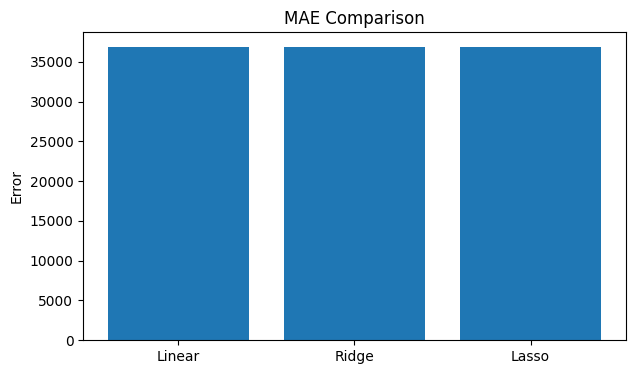

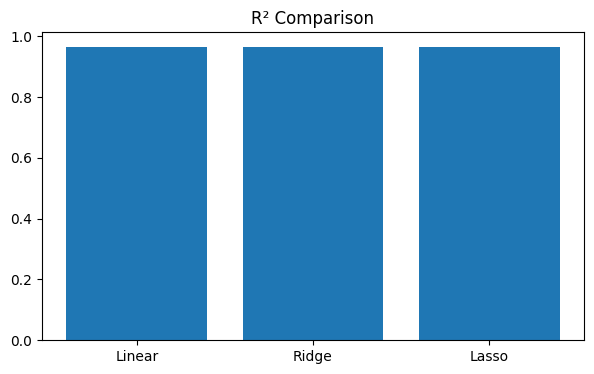

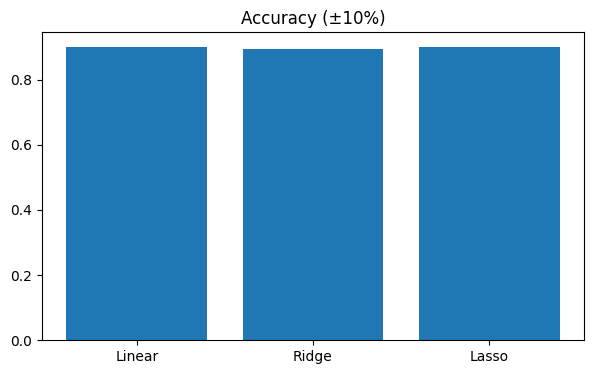

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = ['Linear', 'Ridge', 'Lasso'] # Updated models list

# Extract metrics
mae_vals = [linear_metrics[0], ridge_metrics[0], lasso_metrics[0]] # Updated metrics list
r2_vals = [linear_metrics[1], ridge_metrics[1], lasso_metrics[1]] # Updated metrics list
acc_vals = [linear_metrics[2], ridge_metrics[2], lasso_metrics[2]] # Updated metrics list

# Plot MAE comparison
plt.figure(figsize=(7,4))
plt.bar(models, mae_vals)
plt.title("MAE Comparison")
plt.ylabel("Error")
plt.show()

# Plot R² comparison
plt.figure(figsize=(7,4))
plt.bar(models, r2_vals)
plt.title("R² Comparison")
plt.show()

# Plot Accuracy comparison
plt.figure(figsize=(7,4))
plt.bar(models, acc_vals)
plt.title("Accuracy (±10%)")
plt.show()

**9. Predict New Property Price (Using Best Individual Model: Ridge Regression)**

Based on our initial evaluation (lowest MAE, highest R-squared, and strong accuracy), **Ridge Regression** is identified as the best performing individual model. Therefore, we will use this model for new property price predictions.

In [ ]:
# Assign the best performing model (Ridge Regression) for prediction
best_model = ridge_model

# Take one sample from test set
sample = X_test.iloc[0:1]

# Predict price using the best model
predicted_price = best_model.predict(sample)[0]

# Create price range (±10%)
lower = predicted_price * 0.9
upper = predicted_price * 1.1

print("Predicted Price (using Ridge Regression):", round(predicted_price))
print("Suggested Price Range:", round(lower), "-", round(upper))
print("Actual Price:", y_test.iloc[0])

Predicted Price (using Ridge Regression): 550490
Suggested Price Range: 495441 - 605539
Actual Price: 494000


**10. Comprehensive Model Comparison**

This section provides a comprehensive comparison of all trained models, including the individual Linear, Ridge, and Lasso regressions, and our newly created Ensemble model. We will visually compare their performance across key metrics (MAE, R², Accuracy) and observe their actual vs. predicted price distributions and residual plots to identify the best-performing model(s).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consolidate metrics from all models
models_names = ['Linear', 'Ridge', 'Lasso', 'Ensemble'] # Updated models list
mae_values = [linear_metrics[0], ridge_metrics[0], lasso_metrics[0], ensemble_metrics[0]] # Updated metrics list
r2_values = [linear_metrics[1], ridge_metrics[1], lasso_metrics[1], ensemble_metrics[1]] # Updated metrics list
accuracy_values = [linear_metrics[2], ridge_metrics[2], lasso_metrics[2], ensemble_metrics[2]] # Updated metrics list

# Create a DataFrame for easy plotting and display
comparison_df = pd.DataFrame({
    'Model': models_names,
    'MAE': mae_values,
    'R2': r2_values,
    'Accuracy (±10%)': accuracy_values
})

print("Model Performance Comparison:")
display(comparison_df.sort_values(by='MAE'))

Model Performance Comparison:


,Model,MAE,R2,Accuracy (±10%)
1,Ridge,36852.148016,0.964796,0.895
3,Ensemble,36855.322846,0.964781,0.900
0,Linear,36856.876854,0.964773,0.900
2,Lasso,36856.943669,0.964773,0.900


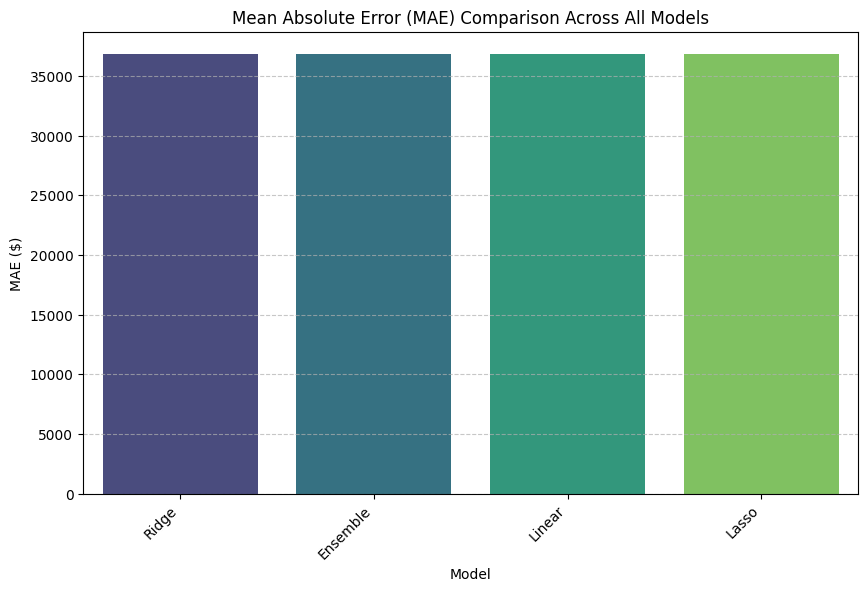

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MAE', data=comparison_df.sort_values(by='MAE'), palette='viridis', hue='Model', legend=False)
plt.title('Mean Absolute Error (MAE) Comparison Across All Models')
plt.ylabel('MAE ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

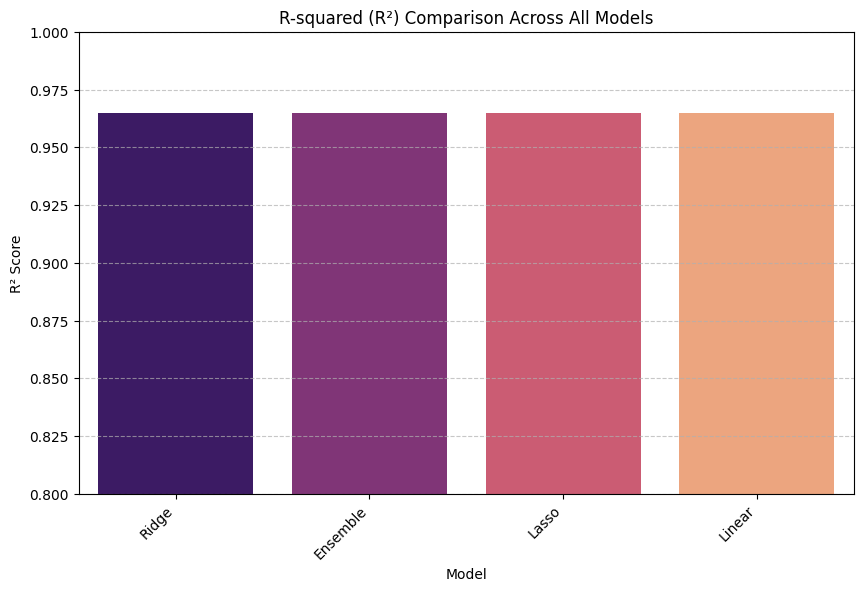

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=comparison_df.sort_values(by='R2', ascending=False), palette='magma', hue='Model', legend=False)
plt.title('R-squared (R²) Comparison Across All Models')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0) # Focus on the relevant R2 range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

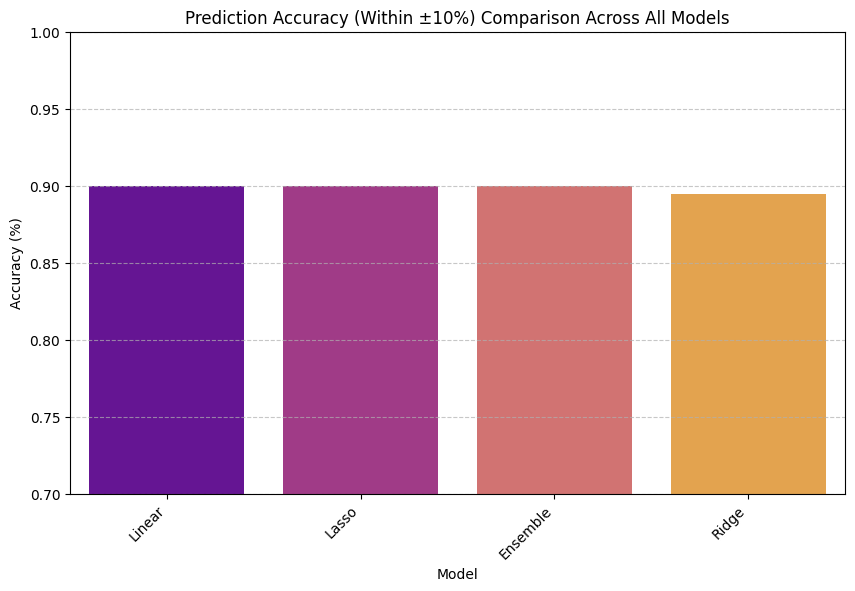

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy (±10%)', data=comparison_df.sort_values(by='Accuracy (±10%)', ascending=False), palette='plasma', hue='Model', legend=False)
plt.title('Prediction Accuracy (Within ±10%) Comparison Across All Models')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0) # Focus on the relevant accuracy range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

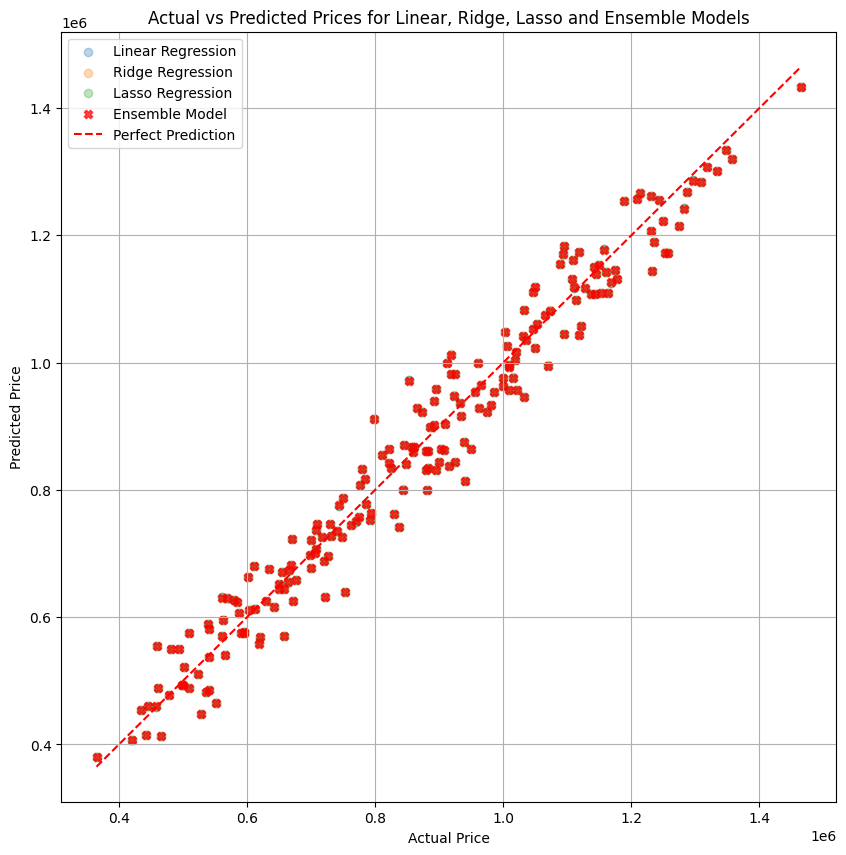

In [ ]:
plt.figure(figsize=(10,10))

# Plot existing models
plt.scatter(y_test, linear_pred, alpha=0.3, label='Linear Regression')
plt.scatter(y_test, ridge_pred, alpha=0.3, label='Ridge Regression')
plt.scatter(y_test, lasso_pred, alpha=0.3, label='Lasso Regression')
plt.scatter(y_test, ensemble_pred, alpha=0.7, label='Ensemble Model', color='red', marker='X') # Highlight ensemble

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices for Linear, Ridge, Lasso and Ensemble Models")

# Perfect prediction reference line
min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red', linestyle='--', label='Perfect Prediction')

plt.legend()
plt.grid(True)
plt.show()

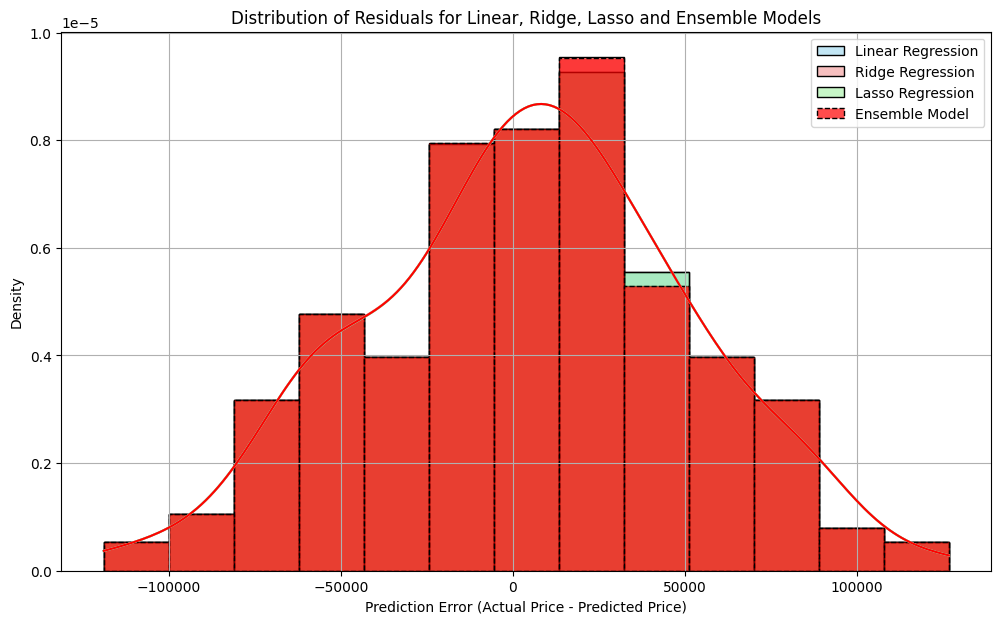

In [ ]:
# Calculate residuals for the ensemble model
ensemble_residuals = y_test - ensemble_pred

plt.figure(figsize=(12, 7))
sns.histplot(linear_residuals, kde=True, color='skyblue', label='Linear Regression', alpha=0.5, stat='density')
sns.histplot(ridge_residuals, kde=True, color='lightcoral', label='Ridge Regression', alpha=0.5, stat='density')
sns.histplot(lasso_residuals, kde=True, color='lightgreen', label='Lasso Regression', alpha=0.5, stat='density')
sns.histplot(ensemble_residuals, kde=True, color='red', label='Ensemble Model', alpha=0.7, stat='density', linestyle='--') # Highlight ensemble

plt.title('Distribution of Residuals for Linear, Ridge, Lasso and Ensemble Models')
plt.xlabel('Prediction Error (Actual Price - Predicted Price)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()